
# REITs P/FFO–g 회귀 (사용자 스키마 전용)
**입력 CSV 스키마**
- `year` : 연도 (예: 2024)
- `period` : 반기 (1 또는 2)
- `ticker` : 종목코드
- `p` : **반기말 시가총액** (단위가 '억'일 수 있음)
- `ffo` : **P/FFO 멀티플**(주가/FFO)

이 노트북은 다음을 수행합니다.
1. CSV 로드 및 단위 정리(억→원 옵션).
2. `TTM_FFO = 시가총액 ÷ (P/FFO)` 역산.
3. `g`(FFO CAGR: 2·3·5년) 계산.
4. **반기별 횡단면 회귀** `P/FFO = α + β·g` 및 산점도 시각화.
5. 롤링 요약표 저장.


In [1]:

# === 사용자 입력 ===
DATA_FILE = "../../data/raw/reit_panel_simple.csv"   # 이 노트북과 같은 폴더에 있는 CSV 파일명
P_IS_EOK = True                       # p가 '억' 단위면 True, 이미 원이면 False
G_COL = "g_2y"                        # 회귀에 쓸 g: g_2y / g_3y / g_5y 중 선택
SAVE_DIR = "../data"                        # 결과 저장 폴더 (기본: 현재 폴더)


In [2]:

import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_any(p):
    for enc in ("utf-8-sig","utf-8","cp949"):
        try:
            return pd.read_csv(p, encoding=enc)
        except Exception as e:
            last = e
    raise last

# 데이터 로드
csv_path = Path(DATA_FILE)
assert csv_path.exists(), f"파일이 존재하지 않습니다: {csv_path}"
raw = read_any(csv_path)
print("원본 컬럼:", list(raw.columns))
display(raw.head())


원본 컬럼: ['year', 'period', 'ticker', 'p', 'ffo']


,year,period,ticker,p,ffo
0,2022,1,395400,"8,464.00",23.1
1,2022,2,395400,9228,49.9
2,2023,1,395400,10000,22.8
3,2023,2,395400,8854.8,22.8
4,2024,1,395400,11000,23.0


In [3]:

# 정리: 숫자형 변환 및 단위(억→원) 처리
df = raw.copy()

def to_float(s):
    s = str(s).strip()
    if s == "" or s.lower() == "nan":
        return np.nan
    s = s.replace(",", "").replace("_","")
    return float(s)

for col in ["p","ffo"]:
    if col in df.columns:
        df[col] = df[col].map(to_float)

# period 라벨
df["period_label"] = df["year"].astype(int).astype(str) + "H" + df["period"].astype(int).astype(str)

# 시가총액(원)
if P_IS_EOK:
    df["mktcap_end"] = df["p"] * 1e8
else:
    df["mktcap_end"] = df["p"]

# P/FFO 멀티플
df["P_FFO"] = df["ffo"]

# TTM_FFO 역산
df["TTM_FFO"] = df["mktcap_end"] / df["P_FFO"]

# 정렬
df = df.sort_values(["ticker","year","period"]).reset_index(drop=True)
display(df.head())


,year,period,ticker,p,ffo,period_label,mktcap_end,P_FFO,TTM_FFO
0,2022,1,395400,8464.0,23.1,2022H1,8.464000e+11,23.1,3.664069e+10
1,2022,2,395400,9228.0,49.9,2022H2,9.228000e+11,49.9,1.849299e+10
2,2023,1,395400,10000.0,22.8,2023H1,1.000000e+12,22.8,4.385965e+10
3,2023,2,395400,8854.8,22.8,2023H2,8.854800e+11,22.8,3.883684e+10
4,2024,1,395400,11000.0,23.0,2024H1,1.100000e+12,23.0,4.782609e+10


In [4]:

# g 계산 (반기 데이터 → n년은 2n 반기 시프트)
def g_from_ttm(df_in, n_years):
    lag = n_years * 2
    ttm = df_in["TTM_FFO"]
    ttm_lag = df_in.groupby("ticker")["TTM_FFO"].shift(lag)
    return (ttm / ttm_lag) ** (1.0/n_years) - 1.0

for n in [2,3,5]:
    df[f"g_{n}y"] = g_from_ttm(df, n)

df[["ticker","period_label","P_FFO","TTM_FFO","g_2y","g_3y","g_5y"]].head(10)


,ticker,period_label,P_FFO,TTM_FFO,g_2y,g_3y,g_5y
0,395400,2022H1,23.1,3.664069e+10,NaN,NaN,NaN
1,395400,2022H2,49.9,1.849299e+10,NaN,NaN,NaN
2,395400,2023H1,22.8,4.385965e+10,NaN,NaN,NaN
3,395400,2023H2,22.8,3.883684e+10,NaN,NaN,NaN
4,395400,2024H1,23.0,4.782609e+10,0.142485,NaN,NaN
5,395400,2024H2,38.4,3.632812e+10,0.401580,NaN,NaN
6,395400,2025H1,21.3,6.103286e+10,0.179639,0.185405,NaN
7,395400,2025H2,21.3,7.042254e+10,0.346585,0.561594,NaN


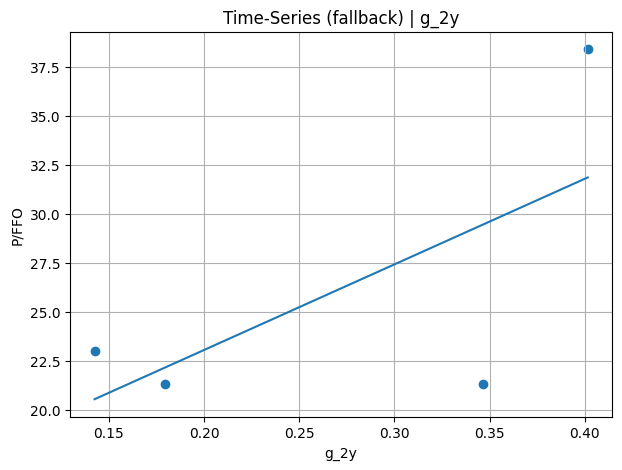

{'alpha': np.float64(14.309156849257231),
 'beta': np.float64(43.69223417549667),
 'R2': nan,
 'n': 4}

In [5]:

# 반기별 횡단면 회귀 (P/FFO = α + β·g)
import numpy as np

def cross_section_reg(df_in, period_label, g_col="g_2y"):
    d = df_in[df_in["period_label"]==period_label].copy()
    d = d.replace([np.inf,-np.inf], np.nan).dropna(subset=["P_FFO", g_col])
    if d["ticker"].nunique() < 3:
        return None
    x = d[g_col].to_numpy()
    y = d["P_FFO"].to_numpy()
    X = np.column_stack([np.ones_like(x), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    a, b = beta[0], beta[1]
    yhat = X @ beta
    r2 = 1 - ((y-yhat)**2).sum() / ((y-y.mean())**2).sum()
    return a, b, r2, d.assign(y_hat=yhat)

def plot_cross_or_timeseries(df_in, period_label, g_col="g_2y"):
    out = cross_section_reg(df_in, period_label, g_col=g_col)
    if out is not None:
        a,b,r2,d = out
        xs = np.linspace(d[g_col].min(), d[g_col].max(), 50)
        ys = a + b*xs
        plt.figure(figsize=(7,5))
        plt.scatter(d[g_col], d["P_FFO"])
        plt.plot(xs, ys)
        plt.title(f"Cross-Section {period_label} | {g_col} | R^2={r2:.3f}")
        plt.xlabel(g_col); plt.ylabel("P/FFO"); plt.grid(True)
        plt.show()
        return {"alpha":a,"beta":b,"R2":r2,"n":len(d)}
    else:
        # 표본 부족 시: 참고용 시계열 산점도
        d = df_in.replace([np.inf,-np.inf], np.nan).dropna(subset=["P_FFO", g_col]).copy()
        d = d.sort_values(["ticker","year","period"])
        x = d[g_col].to_numpy()
        y = d["P_FFO"].to_numpy()
        if len(x) < 3:
            print("표본 부족으로 시각화 생략")
            return None
        X = np.column_stack([np.ones_like(x), x])
        a,b = np.linalg.lstsq(X, y, rcond=None)[0]
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 50)
        ys = a + b*xs
        plt.figure(figsize=(7,5))
        plt.scatter(x, y)
        plt.plot(xs, ys)
        plt.title(f"Time-Series (fallback) | {g_col}")
        plt.xlabel(g_col); plt.ylabel("P/FFO"); plt.grid(True)
        plt.show()
        return {"alpha":a,"beta":b,"R2":np.nan,"n":len(d)}

# 예시 실행
period_pick = df["period_label"].unique()[0]
plot_cross_or_timeseries(df, period_pick, g_col=G_COL)


In [6]:

# 롤링 요약표
def rolling_summary(df_in, g_col="g_2y"):
    rows = []
    for p in sorted(df_in["period_label"].unique()):
        out = cross_section_reg(df_in, p, g_col=g_col)
        if out is None:
            n = df_in[df_in["period_label"]==p]["ticker"].nunique()
            rows.append({"period":p,"alpha":np.nan,"beta":np.nan,"R2":np.nan,"n":n,"note":"insufficient cross-section"})
        else:
            a,b,r2,d = out
            rows.append({"period":p,"alpha":a,"beta":b,"R2":r2,"n":len(d),"note":""})
    return pd.DataFrame(rows)

summary = rolling_summary(df, g_col=G_COL)
summary


,period,alpha,beta,R2,n,note
0,2022H1,NaN,NaN,NaN,1,insufficient cross-section
1,2022H2,NaN,NaN,NaN,1,insufficient cross-section
2,2023H1,NaN,NaN,NaN,1,insufficient cross-section
3,2023H2,NaN,NaN,NaN,1,insufficient cross-section
4,2024H1,NaN,NaN,NaN,1,insufficient cross-section
5,2024H2,NaN,NaN,NaN,1,insufficient cross-section
6,2025H1,NaN,NaN,NaN,1,insufficient cross-section
7,2025H2,NaN,NaN,NaN,1,insufficient cross-section


In [7]:

# 저장
out_dir = Path(SAVE_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(out_dir/"reits_enriched_from_price.csv", index=False, encoding="utf-8-sig")
summary.to_csv(out_dir/"reits_regression_summary.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print(out_dir/"reits_enriched_from_price.csv")
print(out_dir/"reits_regression_summary.csv")


Saved:
..\data\reits_enriched_from_price.csv
..\data\reits_regression_summary.csv
